In [1]:
#Imports
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

if torch.cuda.is_available():
	print("PyTorch is using the GPU")
	GPUCount = torch.cuda.device_count()
	print(f"Found {GPUCount} GPUs")

	for i in range(GPUCount):
		print(f"GPU {i} found: {torch.cuda.get_device_name(i)}")

	device = torch.device("cuda:0")
else:
	print("PyTorch is using the CPU")
	device = torch.device("cpu")

print(f"Selected Device: {device}")

PyTorch is using the GPU
Found 1 GPUs
GPU 0 found: NVIDIA GeForce RTX 5070 Laptop GPU
Selected Device: cuda:0


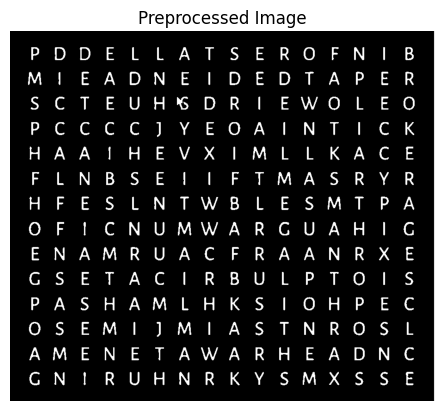

In [2]:
#Kernels
Kernel = cv2.getStructuringElement(shape=cv2.MORPH_RECT,ksize=(2,2))
NewHeight = 800

#Images
InputImg = cv2.imread("TestItems/Test5.png")
Height,Width = InputImg.shape[:2]
Ratio = NewHeight/float(Height)
NewWidth = int(Ratio*Width)
InputImg = cv2.resize(InputImg , (NewWidth,NewHeight) , interpolation=cv2.INTER_AREA)
InputImgGS = cv2.cvtColor(InputImg , cv2.COLOR_BGR2GRAY)
InputImgBlur = cv2.GaussianBlur(src=InputImgGS,ksize=(3,3),sigmaX=0,sigmaY=0)
_,InputImgThresh = cv2.threshold(src=InputImgBlur,thresh=0,maxval=255,type=cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
InputImgMorph = cv2.morphologyEx(src=InputImgThresh,op=cv2.MORPH_CLOSE,kernel=Kernel)
BoxImg = InputImgMorph.copy()
OutputOverlayImg = InputImg.copy()

TestImg = cv2.cvtColor(InputImgMorph, cv2.COLOR_BGR2RGB)
plt.imshow(TestImg)
plt.axis('off')
plt.title("Preprocessed Image")
plt.show()

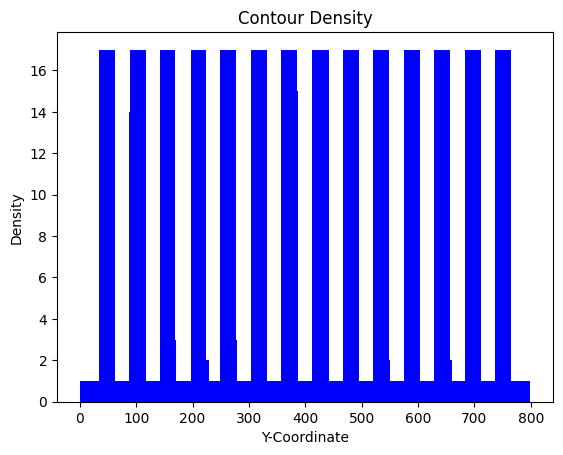

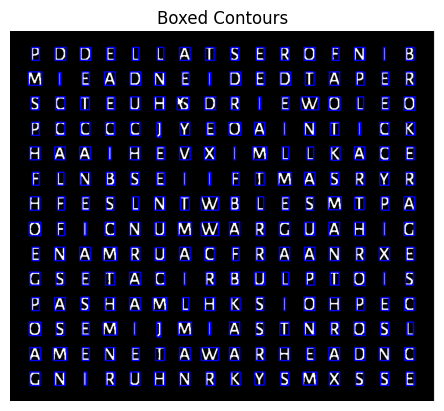

In [3]:
#Detect Contours of each letter and place them in rows

contours,_ = cv2.findContours(InputImgMorph,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
ImgHist = np.zeros(NewHeight,np.int32)
Boxes = []

#Contours exist
if len(contours) > 0:
	AvgArea = sum(cv2.contourArea(contour) for contour in contours)/len(contours)
else:
	AvgArea = 0

for cnt in contours:
	if cv2.contourArea(cnt) < 0.1*AvgArea:
		continue
	x,y,w,h = cv2.boundingRect(cnt)
	Boxes.append((x,y,w,h))

for box in Boxes:
	for i in range(box[1],box[1]+box[3]):
		ImgHist[i] += 1

HistThresh = max(ImgHist)*0.5 #50%
RowRanges = []
InRow = False
StartY = 0

for y in range(len(ImgHist)):
	#Enter Row
	if ImgHist[y] > HistThresh and InRow == False:
		StartY = y
		InRow = True
	#Exit Row
	elif ImgHist[y] <= HistThresh and InRow == True:
		RowRanges.append((StartY,y))
		InRow = False

PuzzleCoords = [[] for _ in range(len(RowRanges))]

for box in Boxes:
	YCenter = box[1]+box[3]/2
	for rowind in range(len(RowRanges)):
		if RowRanges[rowind][0]<=YCenter<=RowRanges[rowind][1]:
			PuzzleCoords[rowind].append(box)
			cv2.rectangle(TestImg,(box[0],box[1]),((box[0]+box[2]),(box[1]+box[3])),(0,0,255),2)

for row in PuzzleCoords:
	row.sort(key=lambda x: x[0])

plt.bar(np.arange(len(ImgHist)),ImgHist,width=1.0,color='blue')
plt.title("Contour Density")
plt.xlabel("Y-Coordinate")
plt.ylabel("Density")
plt.show()

plt.imshow(TestImg)
plt.title("Boxed Contours")
plt.axis('off')
plt.show()

In [4]:
#Load model

print("Loading Model")
#Define architecture
class EMNISTModel(nn.Module):
	def __init__(self):
		super(EMNISTModel,self).__init__()

		#Layer1
		self.conv1 = nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1,bias=False)#Size does not change
		self.bn1 = nn.BatchNorm2d(num_features=32)
		self.relu1 = nn.ReLU()
		self.pool1 = nn.MaxPool2d(kernel_size=2)#Size halves into 14x14

		#Layer2
		self.conv2 = nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3,padding=1,bias=False)
		self.bn2 = nn.BatchNorm2d(num_features=32)
		self.relu2 = nn.ReLU()

		#Layer3
		self.conv3 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,bias=False)
		self.bn3 = nn.BatchNorm2d(num_features=64)
		self.relu3 = nn.ReLU()

		#Layer4
		self.conv4 = nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1,bias=False)
		self.bn4 = nn.BatchNorm2d(num_features=64)
		self.relu4 = nn.ReLU()

		#Layer5
		self.conv5 = nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1,bias=False)
		self.bn5 = nn.BatchNorm2d(num_features=64)
		self.relu5 = nn.ReLU()
		self.pool2 = nn.MaxPool2d(kernel_size=2)#Size halves into 7x7

		#FlattenLayer
		self.flatten = nn.Flatten()

		#Layer6
		self.fc1 = nn.Linear(in_features=64*7*7,out_features=256)
		self.relu6 = nn.ReLU()

		#Layer7
		self.fc2 = nn.Linear(in_features=256,out_features=64)
		self.relu7 = nn.ReLU()

		#DropoutLayer
		self.dropout = nn.Dropout(p=0.2)

		#Layer8
		self.fc3 = nn.Linear(in_features=64,out_features=26)

	def forward(self,x):

		#Pass through Layer1
		x = self.pool1(self.relu1(self.bn1(self.conv1(x))))

		#Pass through Layer2
		x = self.relu2(self.bn2(self.conv2(x)))

		#Pass through Layer3
		x = self.relu3(self.bn3(self.conv3(x)))

		#Pass through Layer4
		x = self.relu4(self.bn4(self.conv4(x)))

		#Pass through Layer5
		x = self.pool2(self.relu5(self.bn5(self.conv5(x))))

		#Pass through Layer5
		x = self.flatten(x)

		#Pass through Layer6
		x = self.relu6(self.fc1(x))

		#Pass through Layer7
		x = self.relu7(self.fc2(x))

		#Pass through DropoutLayer
		x = self.dropout(x)

		#Pass through Layer7
		x = self.fc3(x)

		#Return Prediction
		return x

model = EMNISTModel().to(device)
model.load_state_dict(torch.load("EMNISTModel.pth"))
model.eval()

print("Model Summary: ")
summary(model,input_size=(1,28,28))

Transform = transforms.Compose(
	[
		transforms.Grayscale(num_output_channels=1),
		transforms.ToTensor(),
  		transforms.Normalize((0.5,),(0.5,)),
	])

Loading Model
Model Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             288
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]           9,216
       BatchNorm2d-6           [-1, 32, 14, 14]              64
              ReLU-7           [-1, 32, 14, 14]               0
            Conv2d-8           [-1, 64, 14, 14]          18,432
       BatchNorm2d-9           [-1, 64, 14, 14]             128
             ReLU-10           [-1, 64, 14, 14]               0
           Conv2d-11           [-1, 64, 14, 14]          36,864
      BatchNorm2d-12           [-1, 64, 14, 14]             128
             ReLU-13           [-1, 64, 14, 14]               0
         

P D D E L L A T S E R O F N I B
M I E A D N E I D E D T A P E R
S C T E U H G D R I E W O L E O
P C C C C J Y E O A I N T I C K
H A A I H E V X I M L L K A C E
F L N B S E I I F T M A S R Y R
H F E S L N T W B L E S M T P A
O F I C N U M W A R G U A H I G
E N A M R U A C F R A A N R X E
G S E T A C I R B U L P T O I S
P A S H A M L H K S I O H P E C
O S E M I J M I A S T N R O S L
A M E N E T A W A R H E A D N C
G N I R U H N R K Y S M X S S E


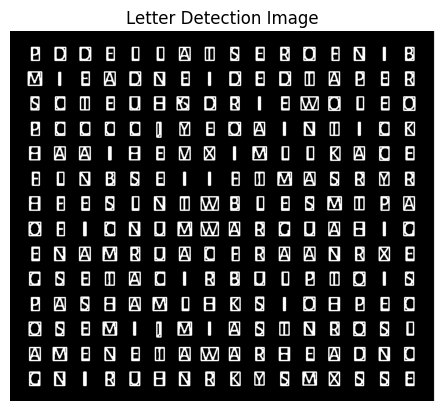

In [5]:
#Pass through model
	
Puzzle = []
inc = 0
LetterWidth = None

for RowCoords in PuzzleCoords:
	Row = []
	for box in RowCoords:
		x,y,w,h = box
		cv2.rectangle(BoxImg,(x,y),(x+w,y+h),(255,0,0),2)
		if not LetterWidth:
			LetterWidth = w
		
		CellImage = InputImgMorph[y:y+h , x:x+w]
		CellImage = Image.fromarray(CellImage)
		CellImage.thumbnail((24,24), Image.Resampling.LANCZOS)

		PillowFrame = Image.new("L", (28, 28), 0)
		PillowFrame.paste(CellImage, ((28 - CellImage.size[0]) // 2, (28 - CellImage.size[1]) // 2))

		CellImage = Transform(PillowFrame)
		CellImage = CellImage.unsqueeze(0)
		CellImage = CellImage.to(device)
		with torch.no_grad():
			output = model(CellImage)
			_,prediction = torch.max(output,dim=1)
			Num = prediction.item()
			Row.append(chr(ord('A')+Num))
			
	Puzzle.append(Row)

for i in Puzzle:
	print(' '.join(i))
	
TestImg = cv2.cvtColor(BoxImg, cv2.COLOR_BGR2RGB)
plt.imshow(TestImg)
plt.title("Letter Detection Image")
plt.axis('off')
plt.show()

In [6]:
#Load WordList

Words = set()

with open('EnglishWords.txt','r',encoding='UTF-8') as file:
	while line := file.readline():
		Words.add(line.strip())

print(f"Loaded {len(Words)} words")

Loaded 359833 words


In [7]:
#Find Words

#Rays
'''
0 = Same Index
1 = Next Index
-1 = Previous Index
(Row,Col)
Right = (0,1)
Left = (0,-1)
Down = (1,0)
Up = (-1,0)
Diagonals = (1,1),(-1,1),(-1,-1),(1,-1)
'''
Rays = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(-1,1),(-1,-1),(1,-1)]

WordsFound = {}

for row in range(len(Puzzle)):
	for col in range(len(Puzzle[row])):
		for RayRow,RayCol in Rays:
			CurrentWord = ""
			CurrentRow,CurrentCol = row,col
			while (True):
				if ((0<=CurrentRow<len(Puzzle))and(0<=CurrentCol<len(Puzzle[row]))):
					CurrentWord += Puzzle[CurrentRow][CurrentCol]
					if (CurrentWord in Words):
						print(f"Found Word {CurrentWord}")
						StartCoords = (row,col)
						CurrentCoords = (CurrentRow,CurrentCol)
						if StartCoords > CurrentCoords:
							StartCoords,CurrentCoords = CurrentCoords,StartCoords
						if CurrentWord not in WordsFound:
							WordsFound[CurrentWord] = [(StartCoords,CurrentCoords)]
						elif ((StartCoords,CurrentCoords) not in WordsFound[CurrentWord]):
							WordsFound[CurrentWord].append((StartCoords,CurrentCoords))

					CurrentRow += RayRow
					CurrentCol += RayCol
				else:
					break

Found Word PITCH
Found Word DELLA
Found Word LATCH
Found Word STALL
Found Word STALLED
Found Word ESTALL
Found Word FORES
Found Word FOREST
Found Word FORESTAL
Found Word FORESTALL
Found Word FORESTALLED
Found Word BROKE
Found Word BROKER
Found Word BROKERAGE
Found Word BROKERAGES
Found Word NUCAL
Found Word DIOXIN
Found Word TAPER
Found Word ROKER
Found Word REVEL
Found Word WEIRD
Found Word YESSING
Found Word ACTED
Found Word VIBRAPHONE
Found Word MODEL
Found Word LARIA
Found Word KNEES
Found Word ARTHROPOD
Found Word ARTHROPODS
Found Word FACED
Found Word LACUNA
Found Word NICHE
Found Word SSING
Found Word FIORD
Found Word FIORDS
Found Word MEGALITHS
Found Word ALARIA
Found Word RAGES
Found Word FLACCID
Found Word ENACT
Found Word ENACTED
Found Word LEVER
Found Word LEVERER
Found Word WARLORD
Found Word WARLORDS
Found Word MALAR
Found Word MALARIA
Found Word TRAIL
Found Word PIXIE
Found Word PIXIES
Found Word CLEVE
Found Word CLEVER
Found Word CLEVERER
Found Word MAILMAN
Found Word 

In [8]:
#Clean substrings

OccupancyMatrix = np.zeros((len(Puzzle),len(Puzzle[0])),np.int8)
WordsFound = sorted(WordsFound.items(),key=lambda word:len(word[0]),reverse=True)
FilteredWords = {}

for word,coords in WordsFound:
	for instance in coords:
		StartCoords,EndCoords = instance
		StartRow,StartCol = StartCoords
		EndRow,EndCol = EndCoords
		Occupied = True
		while ((StartRow,StartCol)!=(EndRow,EndCol)):
			if (OccupancyMatrix[StartRow][StartCol] == 0):
				Occupied = False

			if (StartRow<EndRow):
				StartRow += 1
			elif (StartRow>EndRow):
				StartRow -= 1

			if (StartCol<EndCol):
				StartCol += 1
			elif (StartCol>EndCol):
				StartCol -= 1
		if (OccupancyMatrix[StartRow][StartCol] == 0):
				Occupied = False
				
		if (not Occupied):
			StartRow,StartCol = StartCoords
			if (word not in FilteredWords):
				FilteredWords[word] = []
			FilteredWords[word].append(instance)
			while ((StartRow,StartCol)!=(EndRow,EndCol)):
				OccupancyMatrix[StartRow][StartCol] = 1
				if (StartRow<EndRow):
					StartRow += 1
				elif (StartRow>EndRow):
					StartRow -= 1

				if (StartCol<EndCol):
					StartCol += 1
				elif (StartCol>EndCol):
					StartCol -= 1
			OccupancyMatrix[StartRow][StartCol] = 1

print(OccupancyMatrix)
print(FilteredWords)
print(f"Number of words: {len(FilteredWords)}")

[[1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1]
 [1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
 [1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0]
 [0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0]
 [1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 0 0 1 1 0 0 0 1 1 1 1 1 1]]
{'FORESTALLED': [((0, 2), (0, 12))], 'BROKERAGES': [((0, 15), (9, 15))], 'VIBRAPHONE': [((4, 6), (13, 15))], 'ARTHROPODS': [((4, 13), (13, 13))], 'LUBRICATES': [((9, 1), (9, 10))], 'MENOPAUSAL': [((4, 11), (13, 11))], 'MEGALITHS': [((5, 10), (13, 10))], 'WARLORDS': [((6, 7), (13, 14))], 'CLEVERER': [((0, 10), (7, 3))], 'FREAKIER': [((1, 15), (8, 8))], 'INIMICAL': [((6, 9), (13, 2))], 'YESSING': [((3, 6), (9, 0))], 'FLACCID': [((0, 1), (6, 1))], 'ENACTED': [((0, 2), (6, 2))], 'MALARIA': [((0, 6), (6, 12))

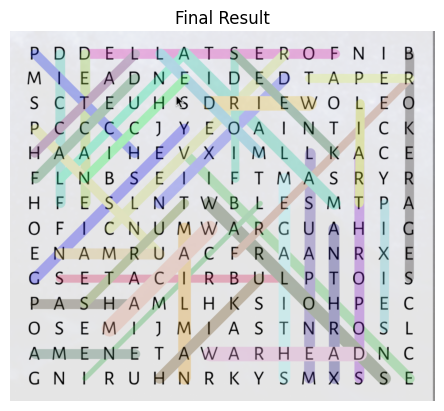

In [9]:
#Highlight words

for word,coords in FilteredWords.items():
	for instance in coords:
		StartInd,EndInd = instance
		StartCoords,EndCoords = PuzzleCoords[StartInd[0]][StartInd[1]],PuzzleCoords[EndInd[0]][EndInd[1]]
		StartCenter = ((StartCoords[0]+StartCoords[2]//2),(StartCoords[1]+StartCoords[3]//2))
		EndCenter = ((EndCoords[0]+EndCoords[2]//2),(EndCoords[1]+EndCoords[3]//2))
		color = tuple(np.random.random(size=3)*256)
		width = (StartCoords[2]+EndCoords[2])//2
		cv2.line(img=OutputOverlayImg,pt1=StartCenter,pt2=EndCenter,color=color,thickness=width,lineType=cv2.LINE_AA)

TestImg = cv2.addWeighted(src1=InputImg,alpha=0.7,src2=OutputOverlayImg,beta=0.3,gamma=0)

TestImg = cv2.cvtColor(TestImg, cv2.COLOR_BGR2RGB)
plt.imshow(TestImg)
plt.axis('off')
plt.title("Final Result")
plt.show()